In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

IMAGES_DIR = PROJECT_ROOT / 'images'
DATA_DIR = PROJECT_ROOT / 'data'

In [2]:
from IPython.display import HTML

In [3]:
import pandas as pd

path= DATA_DIR/ 'Global_Smartwatch_Marketplace.csv'
df = pd.read_csv(path)

pd.set_option('display.max_colwidth', None)

from src.cleaning import clean_dataframe
df = clean_dataframe(df)

from src.feature_engineering import add_model_col, add_family_col
from src.graphics import plot_by
df = add_model_col(df)
df = add_family_col(df)

from src.feature_engineering import add_premium_cols
df = add_premium_cols(df)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

In [4]:





HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

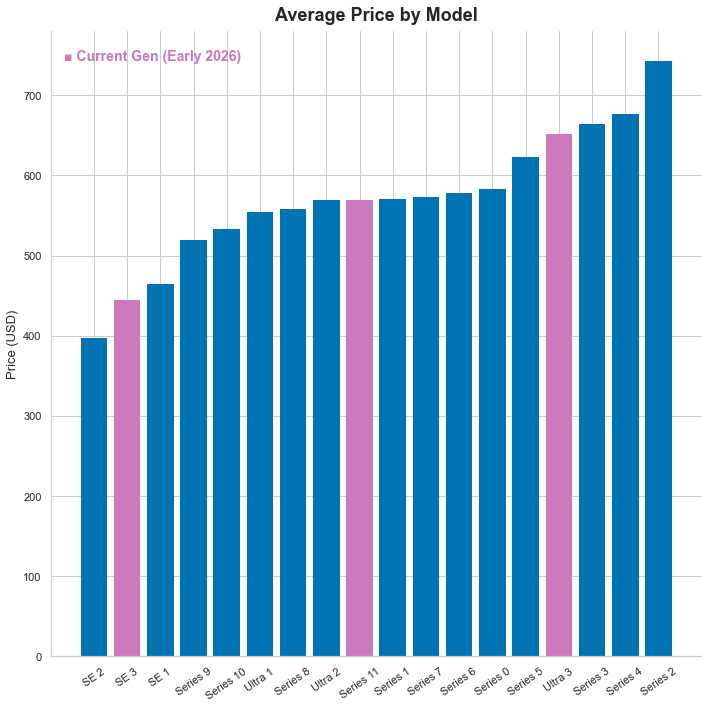

In [5]:
def plot_by(
    df,
    by='mean',
    model_list=None,
    title='Average Resale Prices',
    retail_prices=None,
    save_path=None,
    y_lower=None,
    y_upper=None,
    highlight_models=None,
    highlight_labels=None,
    column='model',
    order=None,
    whiskers=False,
    ax=None,
    figure_size=(10, 10),
    xlabel=None,
    ylabel=None
):
    """
    Compact README-friendly bar chart.

    Optimized for:
    - GitHub README display
    - Internal highlight labels
    - Reduced whitespace
    - Readability on desktop and mobile
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Patch

    df_plot = df.copy()

    # --- Optional filtering ---
    if model_list is None:
        model_list = list(df[column].dropna().unique())

    if model_list is not None:
        df_plot = df_plot[df_plot[column].isin(model_list)]

    # --- Aggregate ---
    if by == 'count':
        plot_df = (
            df_plot.groupby(column)['price']
            .agg([by])
            .sort_values(by)
            .reset_index()
        )
    else:
        plot_df = (
            df_plot.groupby(column)['price']
            .agg([by, 'count'])
            .sort_values(by)
            .reset_index()
        )

    # --- Custom ordering ---
    if order is not None:

        plot_df[column] = pd.Categorical(
            plot_df[column],
            categories=order,
            ordered=True
        )

        plot_df = plot_df.sort_values(column)

    sns.set_theme(style="whitegrid")

    # --- Create figure if needed ---
    if ax is None:
        fig, ax = plt.subplots(figsize=figure_size)
    else:
        fig = ax.figure

    palette = sns.color_palette("colorblind")

    # ==================================================
    # Highlight logic
    # ==================================================

    if highlight_models is None:

        colors = [palette[0]] * len(plot_df)
        highlight_info = []

    elif isinstance(highlight_models[0], list):

        highlight_groups = highlight_models

        if highlight_labels is None:
            highlight_labels = [
                f'Group {i+1}'
                for i in range(len(highlight_groups))
            ]

        colors = [palette[0]] * len(plot_df)

        color_idx = 4
        base_color = palette[color_idx]

        highlight_info = []

        for i, group in enumerate(highlight_groups):

            alpha = 1.0 if i == 0 else 0.55

            for idx, item in enumerate(plot_df[column]):

                if item in group:
                    colors[idx] = (
                        *base_color[:3],
                        alpha
                    )

            highlight_info.append(
                (base_color, highlight_labels[i], alpha)
            )

    else:

        colors = [
            (*palette[4][:3], 1.0)
            if item in highlight_models
            else palette[0]
            for item in plot_df[column]
        ]

        highlight_info = [
            (palette[4], 'Current Gen (2026)', 1.0)
        ]

    x = np.arange(len(plot_df))

    # ==================================================
    # No retail comparison
    # ==================================================

    if retail_prices is None:

        ax.bar(
            x,
            plot_df[by],
            color=colors,
            edgecolor='none'
        )

        ax.set_xticks(x)
        ax.set_xticklabels(plot_df[column])

    # ==================================================
    # Retail comparison
    # ==================================================

    else:

        width = 0.38

        retail_low = []
        retail_high = []
        retail_mid = []

        for item in plot_df[column]:

            if item in retail_prices:

                low, high = retail_prices[item]

                retail_low.append(low)
                retail_high.append(high)
                retail_mid.append((low + high) / 2)

            else:

                retail_low.append(np.nan)
                retail_high.append(np.nan)
                retail_mid.append(np.nan)

        retail_low = np.array(retail_low)
        retail_high = np.array(retail_high)
        retail_mid = np.array(retail_mid)

        ax.bar(
            x - width / 2,
            plot_df[by],
            width=width,
            color=colors,
            edgecolor='none',
            label='Average resale'
        )

        ax.bar(
            x + width / 2,
            retail_mid,
            width=width,
            color=palette[1],
            alpha=0.85,
            label='Retail price'
        )

        if whiskers:

            ax.errorbar(
                x + width / 2,
                retail_mid,
                yerr=[
                    retail_mid - retail_low,
                    retail_high - retail_mid
                ],
                fmt='none',
                ecolor='black',
                capsize=4,
                linewidth=1
            )

        ax.set_xticks(x)
        ax.set_xticklabels(plot_df[column])

    # ==================================================
    # Labels
    # ==================================================

    ax.set_xlabel(
        xlabel,
        fontsize=13
    )

    ax.set_ylabel(
        ylabel,
        fontsize=13
    )

    ax.tick_params(
        axis='x',
        rotation=35,
        labelsize=11
    )

    ax.tick_params(
        axis='y',
        labelsize=11
    )

    ax.set_title(
        title,
        fontsize=18,
        fontweight='bold',
        pad=10
    )

    ax.set_ylim(
        y_lower,
        y_upper
    )

    # ==================================================
    # Retail legend
    # ==================================================

    handles, labels = ax.get_legend_handles_labels()

    if len(handles) > 0:

        ax.legend(
            handles=handles,
            loc='upper right',
            fontsize=10,
            frameon=True,
            framealpha=0.95
        )

    # ==================================================
    # Internal highlight label
    # ==================================================

    if highlight_models is not None:

        if isinstance(highlight_models[0], list):

            y_pos = 0.97

            for color, label, alpha in highlight_info:

                ax.text(
                    0.02,
                    y_pos,
                    f'■ {label}',
                    transform=ax.transAxes,
                    ha='left',
                    va='top',
                    fontsize=11,
                    color=color,
                    alpha=alpha,
                    fontweight='bold'
                )

                y_pos -= 0.055

        else:

            ax.text(
                0.02,
                0.97,
                '■ Current Gen (Early 2026)',
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=14,
                color=palette[4],
                fontweight='bold'
            )

    sns.despine()

    fig.tight_layout()

    if save_path is not None:

        fig.savefig(
            save_path,
            bbox_inches='tight',
            dpi=300
        )

    if ax is None:
        plt.show()
        
        
        
current_gen_models = ['Ultra 3', 'Series 11', 'SE 3']
      
plot_by(df,
        by='mean',
        title = 'Average Price by Model',
        save_path=IMAGES_DIR / 'md_price_by_model_all.png',
        highlight_models = current_gen_models,
        highlight_labels = ['Current gen'],
        ylabel = 'Price (USD)'
       )



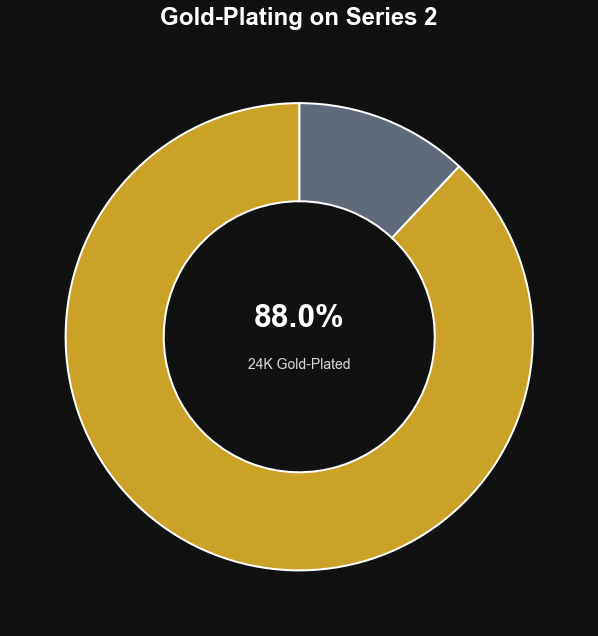

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Filter Series 2 listings ---
def plot_gold_donut(df):
    df_plot = df[df['model'].str.lower().str.contains('series 2', na=False)].copy()

    if len(df_plot) == 0:
        raise ValueError("No Series 2 listings found.")

    # --- Premium flag ---
    df_plot['premium'] = df_plot['gold'].fillna(0).astype(int)

    gold_count = (df_plot['premium'] == 1).sum()
    standard_count = (df_plot['premium'] == 0).sum()

    if gold_count + standard_count == 0:
        raise ValueError("No valid data to plot.")

    gold_pct = gold_count / (gold_count + standard_count) * 100

    # --- Styling ---
    sns.set_theme(style="white")

    bg_color = "#111111"
    gold_color = "#C9A227"
    standard_color = "#5F6B7A"

    fig, ax = plt.subplots(figsize=(9, 9))

    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)

    sizes = [standard_count, gold_count]
    labels = ['', "2"]

    # --- Donut chart ---
    wedges, _ = ax.pie(
        sizes,
        colors=[standard_color, gold_color],
        startangle=90,
        counterclock=False,
        wedgeprops={
            "width": 0.42,
            "edgecolor": "white",
            "linewidth": 2
        }
    )

    # --- Center metric ---
    ax.text(
        0,
        0.08,
        f"{gold_pct:.1f}%",
        ha="center",
        va="center",
        fontsize=32,
        fontweight="bold",
        color="white"
    )

    ax.text(
        0,
        -0.12,
        "24K Gold-Plated",
        ha="center",
        va="center",
        fontsize=14,
        color="#D9D9D9"
    )

    # --- Title ---
    ax.set_title(
        "Gold-Plating on Series 2",
        fontsize=24,
        fontweight="bold",
        pad=20,
        color="white"
    )

    # # --- Subtitle ---
    # fig.text(
    #     0.5,
    #     0.88,
    #     "Share of listings featuring a 24k gold-plated finish",
    #     ha="center",
    #     fontsize=12,
    #     color="#B0B0B0"
    # )

    # --- Gold accent line ---
    ax.plot(
        [0.35, 0.65],
        [1.08, 1.08],
        transform=ax.transAxes,
        color=gold_color,
        linewidth=5,
        solid_capstyle="round"
    )

   # --- Legend ---
#     legend = ax.legend(
#         wedges,
#         labels,
#         loc="lower center",
#         bbox_to_anchor=(0.5, -0.08),
#         ncol=2,
#         frameon=False,
#         fontsize=13
#     )

#     for text in legend.get_texts():
#         text.set_color("white")

    # --- Final touches ---
    ax.set_aspect("equal")

    # --- Save ---
    save_path = IMAGES_DIR / "md_gold_donut.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.tight_layout()
    plt.show()
    
plot_gold_donut(df)

In [330]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_gold_cloud(
    df,

    # --------------------------------------------------
    # DONUT CENTERS (0–1 figure coordinates)
    # --------------------------------------------------

    s2_center=(0.50, 0.35),
    s3_center=(0.20, 0.62),
    s4_center=(0.80, 0.60),

    # --------------------------------------------------
    # DONUT SIZES
    # --------------------------------------------------

    s2_size=0.58,
    s3_size=0.30,
    s4_size=0.18,

    # --------------------------------------------------
    # TEXT INSIDE DONUTS
    # --------------------------------------------------

    label_y=0.12,
    pct_y=-0.12,

    # --------------------------------------------------
    # FIGURE
    # --------------------------------------------------

    figsize= (16, 9),

    # --------------------------------------------------
    # TITLE
    # --------------------------------------------------

    title_text="24K Gold-Plated",
    title_x=0.50,
    title_y=0.95,
    title_fontsize=36,
    title_color="white",

    # --------------------------------------------------
    # ACCENT LINE
    # --------------------------------------------------

    line_x0=0.32,
    line_x1=0.68,
    line_y=0.92,
    line_width=6,

    # --------------------------------------------------
    # DEBUG
    # --------------------------------------------------

    show_axes=False
):

    # --------------------------------------------------
    # Styling
    # --------------------------------------------------

    sns.set_theme(style="white")

    bg_color = "#111111"
    gold_color = "#C9A227"
    standard_color = "#5F6B7A"

    # --------------------------------------------------
    # Compute gold percentages
    # --------------------------------------------------

    results = {}

    for series in ["Series 2", "Series 3", "Series 4"]:

        df_series = df[
            df["model"]
            .str.lower()
            .str.contains(series.lower(), na=False)
        ].copy()

        if len(df_series) == 0:
            continue

        df_series["premium"] = (
            df_series["gold"]
            .fillna(0)
            .astype(int)
        )

        pct_gold = (
            df_series["premium"]
            .mean()
            * 100
        )

        results[series] = pct_gold

    if len(results) == 0:
        raise ValueError(
            "No matching Series 2 / 3 / 4 listings found."
        )

    # --------------------------------------------------
    # Manual layout using CENTER coordinates
    # --------------------------------------------------

    layout = {
        "Series 2": {
            "center": s2_center,
            "size": s2_size
        },
        "Series 3": {
            "center": s3_center,
            "size": s3_size
        },
        "Series 4": {
            "center": s4_center,
            "size": s4_size
        }
    }

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor(bg_color)

    # --------------------------------------------------
    # Title
    # --------------------------------------------------

    fig.text(
        title_x,
        title_y,
        title_text,
        ha="center",
        va="center",
        fontsize=title_fontsize,
        fontweight="bold",
        color=title_color
    )

    # --------------------------------------------------
    # Accent line
    # --------------------------------------------------

    fig.lines.append(
        plt.Line2D(
            [line_x0, line_x1],
            [line_y, line_y],
            transform=fig.transFigure,
            color=gold_color,
            linewidth=line_width,
            solid_capstyle="round"
        )
    )

    # --------------------------------------------------
    # Draw donuts
    # --------------------------------------------------

    for series, pct_gold in results.items():

        if series not in layout:
            continue

        cx, cy = layout[series]["center"]
        size = layout[series]["size"]

        # Convert center coords to add_axes coords
        left = cx - size / 2
        bottom = cy - size / 2

        ax = fig.add_axes([
            left,
            bottom,
            size,
            size
        ])

        if show_axes:
            ax.set_facecolor("#222222")
        else:
            ax.set_facecolor(bg_color)

        ax.pie(
            [100 - pct_gold, pct_gold],
            colors=[
                standard_color,
                gold_color
            ],
            startangle=90,
            counterclock=False,
            wedgeprops={
                "width": 0.40,
                "edgecolor": "white",
                "linewidth": 2
            }
        )

        # --------------------------------------
        # Scale fonts with donut size
        # --------------------------------------

        pct_font = 12 + size * 50
        label_font = 7 + size * 28

        # --------------------------------------
        # Center labels
        # --------------------------------------

        ax.text(
            0,
            label_y,
            series,
            ha="center",
            va="center",
            fontsize=label_font,
            color="white",
            fontweight="bold"
        )

        ax.text(
            0,
            pct_y,
            f"{pct_gold:.1f}%",
            ha="center",
            va="center",
            fontsize=pct_font,
            color="white",
            fontweight="bold"
        )

        ax.set_aspect("equal")
        ax.axis("off")
        
    # --- Save ---
    save_path = IMAGES_DIR / "md_gold_cloud.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.show()




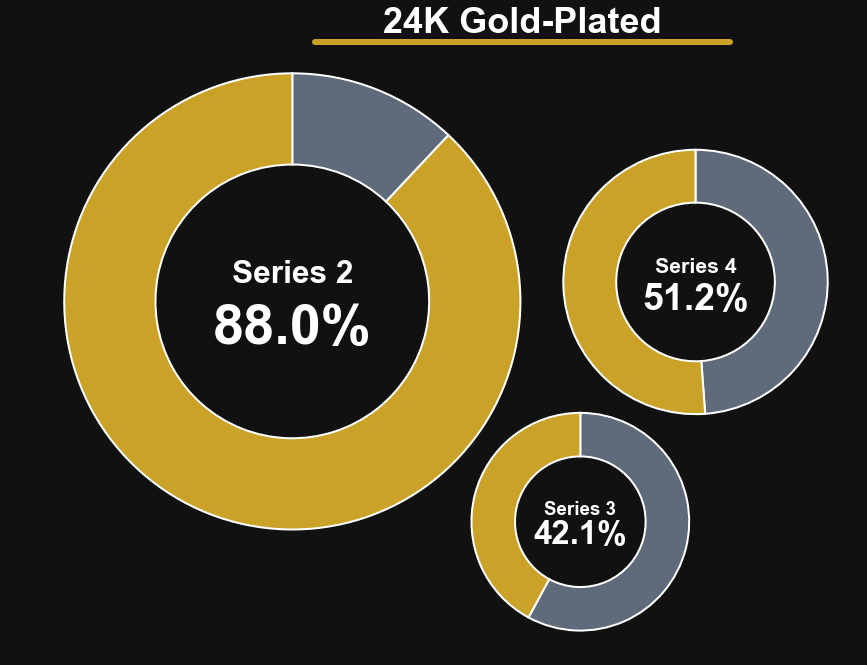

In [336]:
# --------------------------------------------------
# Example Usage
# --------------------------------------------------

plot_gold_cloud(
    df,
    
    s2_center=(0.30, 0.52),
    s4_center=(0.65, 0.55),
    s3_center=(0.55, 0.18),

    # Sizes
    s2_size=0.88,
    s3_size=0.42,
    s4_size=0.51,

    # Text
    label_y=0.12,
    pct_y=-0.12,

    # Title
    title_y=0.95,
    title_fontsize=36,

    # Accent line
    line_y=0.92
)

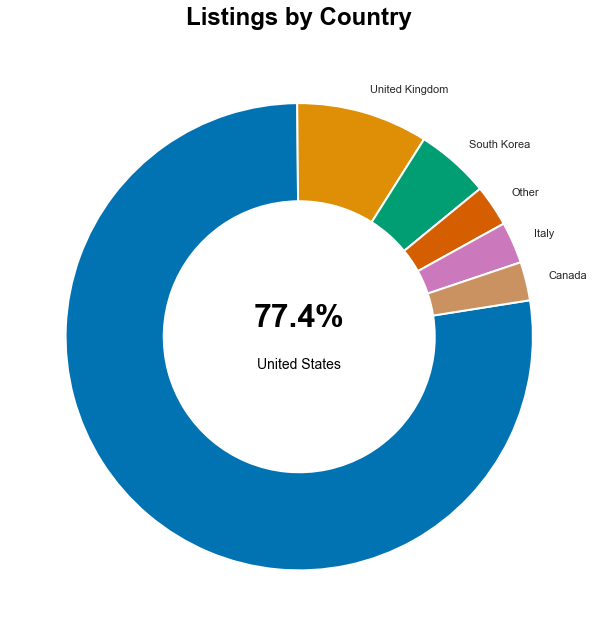

In [7]:
def plot_country_donut(df):
    df_copy = df.copy()

    # Group rare countries into Other
    other_countries = [
        country 
        for country in df['country'].value_counts().index 
        if (df_copy['country'].value_counts().loc[country] < 20)
    ]

    df_copy = df_copy.replace({country:'Other' for country in other_countries})

    # Create country counts
    plot_country = df_copy['country'].value_counts().reset_index()
    plot_country.rename(columns = {'index':'Country', 'country':'frequency'}, inplace=True)

    countries = plot_country['Country']
    counts = plot_country['frequency']

    # United States Percent
    US_count = plot_country.loc[plot_country['Country'] == 'United States', 'frequency'].iloc[0]
    total_count = plot_country['frequency'].sum()

    US_pct = 100*US_count / total_count

    # Donut lables exclude US
    labels_no_us = ['' if country == 'United States' else country for country in countries]


    # Create figure
    fig, ax = plt.subplots(figsize=(9, 9))

    colors = sns.color_palette('colorblind')
    
    wedges, texts = ax.pie(
        counts,
        labels=labels_no_us,
        colors=colors,
        startangle=9,
        counterclock=False,
        wedgeprops={
                "width": 0.42,
                "edgecolor": "white",
                "linewidth": 2
            }
    )


    # Labels
    ax.text(
            0,
            0.08,
            f"{US_pct:.1f}%",
            ha="center",
            va="center",
            fontsize=32,
            fontweight="bold",
            color="black"
        )

    ax.text(
        0,
        -0.12,
        "United States",
        ha="center",
        va="center",
        fontsize=14,
        color="black"
    )
    
    # --- Title ---
    ax.set_title(
        "Listings by Country",
        fontsize=24,
        fontweight="bold",
        pad=20,
        color="black"
    )

    
    
    
    # --- Final touches ---
    ax.set_aspect("equal")

    # --- Save ---
    save_path = IMAGES_DIR / "md_country_donut.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.tight_layout()
    plt.show()
    
    
    
plot_country_donut(df)

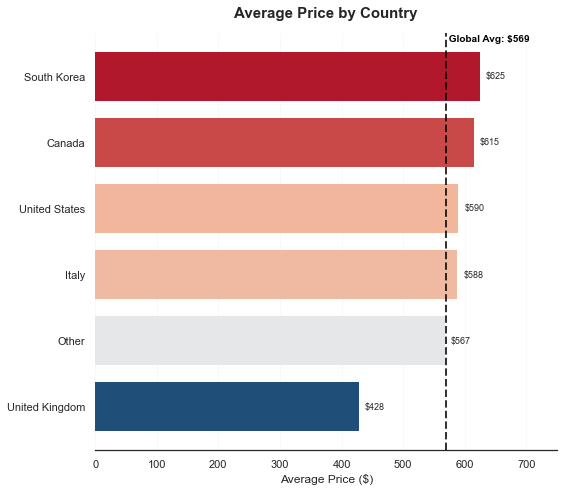

In [8]:

def plot_country_means(df):

    country_means = df.groupby('country')['price'].agg(['mean', 'count']).reset_index()

    other_countries = [scountry for scountry in country_means['country'] if 
                      country_means.loc[country_means['country']==scountry, 'count'].iloc[0] < 20]

    other_mean = country_means.loc[country_means['country'].isin(other_countries)]['mean'].mean()
    other_sum = country_means.loc[country_means['country'].isin(other_countries)]['count'].sum()


    country_means.loc[country_means['country'].isin(other_countries), 'mean'] = other_mean
    #country_means.loc[country_means['country'].isin(other_countries), 'count'] = other_sum

    country_means.replace({scountry: 'Other' for scountry in other_countries}, inplace=True)

    country_means = country_means.groupby('country').agg({
        'mean': 'mean',
        'count': 'sum'
    }).reset_index()


    # Select only country and mean
    price_df = country_means[['country', 'mean']].copy()

    # Sort by price
    price_df = price_df.sort_values('mean').reset_index(drop=True)

    # Global average
    global_avg = price_df['mean'].mean()

    # --------------------------------------------------
    # Professional diverging palette
    # Below average = blue
    # Above average = red
    # --------------------------------------------------
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'professional_diverging',
        [
            '#1f4e79',   # dark blue
            '#6baed6',   # medium blue
            '#e8e8e8',   # neutral center
            '#f4a582',   # light red
            '#b2182b'    # dark red
        ]
    )

    # Center colors on the average
    norm = mcolors.TwoSlopeNorm(
        vmin=price_df['mean'].min(),
        vcenter=global_avg,
        vmax=price_df['mean'].max()
    )

    colors = cmap(norm(price_df['mean']))

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 7))

    bars = ax.barh(
        price_df['country'],
        price_df['mean'],
        color=colors,
        edgecolor='none',
        height=0.75
    )

    # Value labels
    offset = price_df['mean'].max() * 0.015

    for bar, value in zip(bars, price_df['mean']):
        ax.text(
            value + offset,
            bar.get_y() + bar.get_height()/2,
            f'${value:.0f}',
            va='center',
            fontsize=9
        )

    # Average line
    ax.axvline(
        global_avg,
        color='black',
        linestyle='--',
        linewidth=2,
        alpha=0.8,
        zorder=5
    )

    ax.text(
        global_avg,
        len(price_df) - 0.5,
        f' Global Avg: ${global_avg:.0f}',
        ha='left',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

    # Styling
    ax.set_title(
        'Average Price by Country',
        fontsize=15,
        fontweight='bold',
        pad=15
    )

    ax.set_xlabel(
        'Average Price ($)',
        fontsize=12
    )

    ax.set_ylabel('')

    # Subtle x-grid only
    ax.grid(
        axis='x',
        linestyle=':',
        linewidth=0.8,
        alpha=0.4
    )

    ax.set_axisbelow(True)

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Padding for labels
    ax.set_xlim(
        0,
        price_df['mean'].max() * 1.20
    )

    # --- Save ---
    save_path = IMAGES_DIR / "md_country_means.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.tight_layout()
    plt.show()
    
plot_country_means(df)

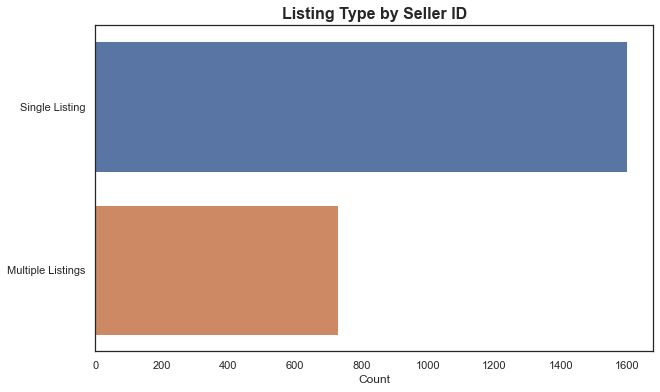

In [9]:
def plot_listing_type_count(df):

    df_copy = df.copy()

    seller_counts = df_copy['seller_id'].value_counts()

    df_copy['power_seller'] = (
        df_copy['seller_id']
        .map(seller_counts > 5)
        .astype(int)
    )

    # Counts
    seller_count = (
        df_copy['power_seller']
        .value_counts()
        .rename(index={
            0: 'Single Listing',
            1: 'Multiple Listings'
        })
        .reset_index()
    )

    seller_count.columns = ['listing_type', 'count']

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=seller_count,
        x='count',
        y='listing_type',
        orient='h',
        ax=ax
    )

    ax.set_title(
        'Listing Type by Seller ID',
        fontsize=16,
        fontweight='bold'
    )

    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('')

    # Save
    save_path = IMAGES_DIR / "md_listing_type_count.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.show()
    
plot_listing_type_count(df)

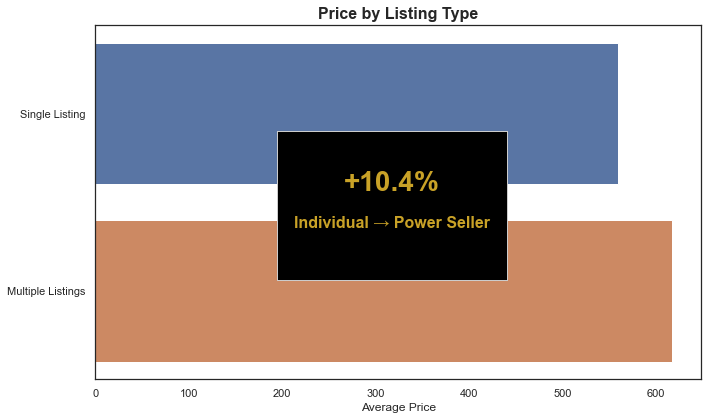

In [10]:
def plot_listing_type_mean(df):
    #Create the df power seller

    df_copy = df.copy()

    seller_counts = df_copy['seller_id'].value_counts()

    df_copy['power_seller'] = df_copy['seller_id'].map(seller_counts > 5).astype(int)


    # Means and counts
    seller_mean = df_copy.groupby('power_seller')['price'].mean().reset_index()
    seller_mean.rename({0:'Single Listing', 1:'Multiple Listings'}, inplace=True)

    seller_count = df_copy['power_seller'].value_counts().reset_index()
    seller_count.rename({0: 'Single Listing', 1: 'Multiple listings'}, inplace=True)


    individual_price = seller_mean['price'].iloc[0]
    power_seller_price = seller_mean['price'].iloc[1]

    pct_diff = (power_seller_price / individual_price - 1) * 100

    fig, ax = plt.subplots(figsize=(10, 6))

    # Main chart
    sns.barplot(
        x=seller_mean['price'],
        y=seller_mean.index,
        orient='h',
        ax=ax
    )

    ax.set_title(
        'Price by Listing Type',
        fontsize=16,
        fontweight='bold'
    )

    # ---------------------------------
    # Floating KPI card
    # ---------------------------------

    ax_card = ax.inset_axes([0.3, 0.28, 0.38, 0.42])

    ax_card.set_facecolor('black')

    # Optional border
    for spine in ax_card.spines.values():
        spine.set_color('0.8')
        spine.set_linewidth(1)

    ax_card.set_xticks([])
    ax_card.set_yticks([])

    ax_card.text(
        0.5,
        0.60,
        f'+{pct_diff:.1f}%',
        ha='center',
        fontsize=28,
        color="#C9A227",
        fontweight='bold'
    )

    ax_card.text(
        0.5,
        0.35,
        'Individual → Power Seller',
        ha='center',
        color="#C9A227",
        fontweight="bold",
        fontsize=16
    )

    plt.xlabel('Average Price')

    # --- Save ---
    save_path = IMAGES_DIR / "md_listing_type_mean.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.tight_layout()
    plt.show()
    
    
plot_listing_type_mean(df)


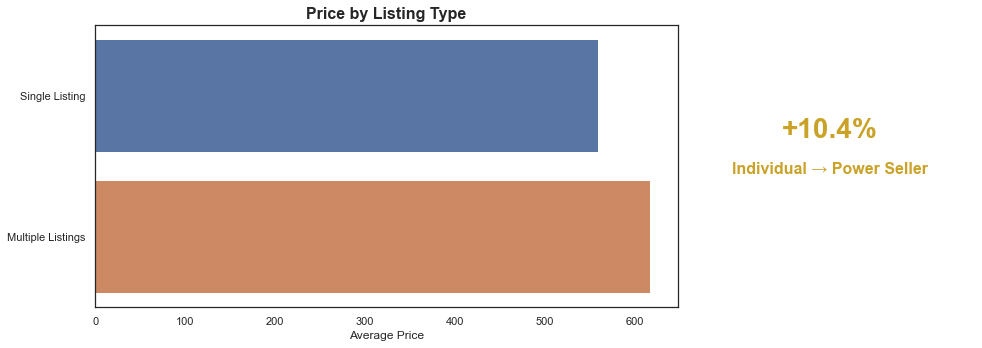

In [11]:
def plot_listing_type_mean2(df):
    #Create the df power seller

    df_copy = df.copy()

    seller_counts = df_copy['seller_id'].value_counts()

    df_copy['power_seller'] = df_copy['seller_id'].map(seller_counts > 5).astype(int)


    # Means and counts
    seller_mean = df_copy.groupby('power_seller')['price'].mean().reset_index()
    seller_mean.rename({0:'Single Listing', 1:'Multiple Listings'}, inplace=True)

    seller_count = df_copy['power_seller'].value_counts().reset_index()
    seller_count.rename({0: 'Single Listing', 1: 'Multiple listings'}, inplace=True)


    individual_price = seller_mean['price'].iloc[0]
    power_seller_price = seller_mean['price'].iloc[1]

    pct_diff = (power_seller_price / individual_price - 1) * 100

    fig, ax = plt.subplots(figsize=(16, 5))

    # Main chart
    sns.barplot(
        x=seller_mean['price'],
        y=seller_mean.index,
        orient='h',
        ax=ax
    )

    ax.set_title(
        'Price by Listing Type',
        fontsize=16,
        fontweight='bold'
    )

    # ---------------------------------
    # Floating KPI card
    # ---------------------------------

    ax_card = ax.inset_axes([1.01, .3, 0.5, 0.5])

    ax_card.set_facecolor('white')

    # Optional border
    for spine in ax_card.spines.values():
        spine.set_color('0.8')
        spine.set_linewidth(0)

    ax_card.set_xticks([])
    ax_card.set_yticks([])

    ax_card.text(
        0.5,
        0.60,
        f'+{pct_diff:.1f}%',
        ha='center',
        fontsize=28,
        color="#C9A227",
        fontweight='bold'
    )

    ax_card.text(
        0.5,
        0.35,
        'Individual → Power Seller',
        ha='center',
        color="#C9A227",
        fontweight="bold",
        fontsize=16
    )

    plt.xlabel('Average Price')

    # --- Save ---
    save_path = IMAGES_DIR / "md_listing_type_mean2.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.tight_layout()
    plt.show()
    
    
plot_listing_type_mean2(df)


In [12]:
conditions = df.groupby('condition')['price'].mean()

conditions = conditions.sort_values()

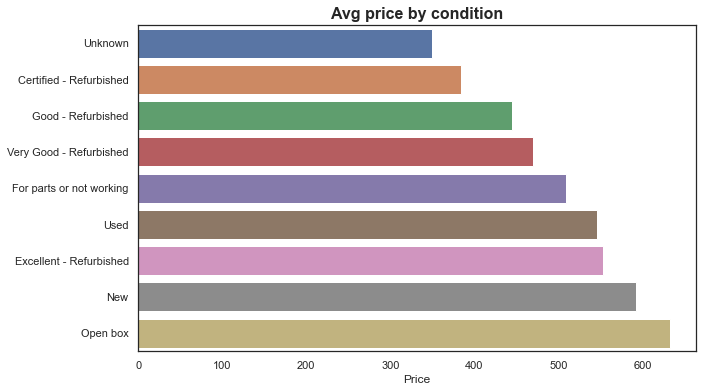

In [13]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    #data=conditions,
    x= conditions.values,
    y= conditions.index,
    orient='h',
    ax=ax
)

ax.set_title(
    'Avg price by condition',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Price', fontsize=12)
ax.set_ylabel('')

# # Save
# save_path = IMAGES_DIR / "md_listing_type_count.png"

# fig.savefig(
#     save_path,
#     bbox_inches="tight",
#     dpi=300,
#     facecolor=fig.get_facecolor()
# )

plt.show()

In [14]:
models = df.groupby('model')['price'].mean().reset_index().sort_values(by='price')

In [15]:
models

,model,price
1,SE 2,396.624286
2,SE 3,444.245000
0,SE 1,464.930476
14,Series 9,519.214341
5,Series 10,533.149847
15,Ultra 1,553.930087
13,Series 8,557.967155
16,Ultra 2,569.001032
6,Series 11,569.337151
4,Series 1,570.537273


In [74]:
def plot_price_by_model_2(df, palette = 'Blues_d'):
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 9))

    colors = sns.color_palette('colorblind')

    sns.barplot(
        #data=conditions,
        x= models['model'],
        y= models['price'],
        orient='v',
        ax=ax,
        palette = palette
    )

    ax.set_title(
        'Price by Model',
        fontsize=24,
        fontweight='bold'
    )

    ax.set_xlabel('Average Price', fontsize=14)
    ax.set_ylabel('')
    
    ax.tick_params(axis='x', labelsize=14, rotation=45)
    ax.tick_params(axis='y', labelsize=14)

    # Save
    save_path = IMAGES_DIR / "md_price_by_model_2.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.show()

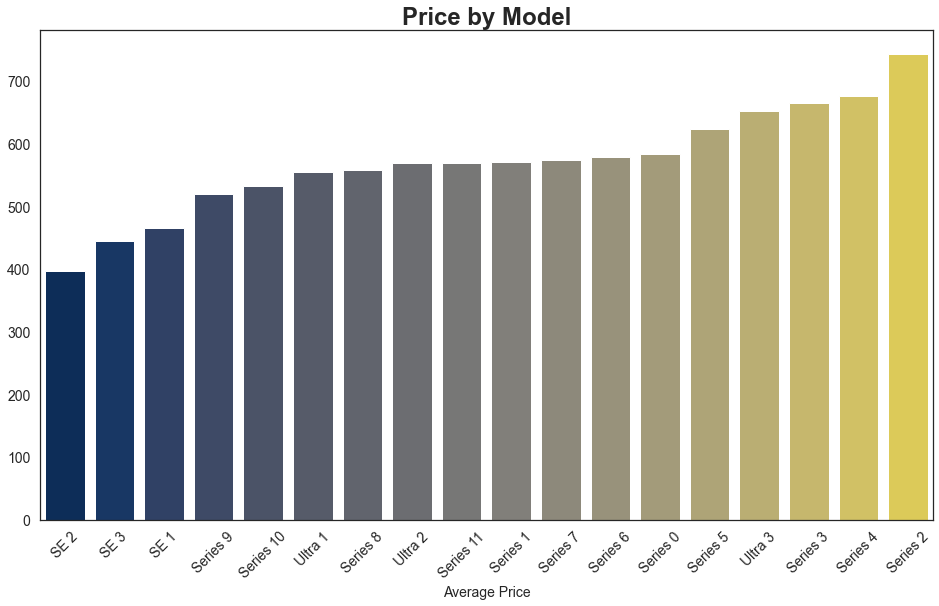

In [75]:
plot_price_by_model_2(df, palette = 'cividis')

In [341]:
df['model'].value_counts()

Ultra 2      562
Ultra 3      341
Ultra 1      229
Series 10    196
Series 11    186
Series 9     129
Series 7     127
Series 6     118
Series 8     116
Series 5      49
SE 3          44
Series 4      43
Series 3      38
Series 2      25
SE 1          21
Series 0      14
Series 1      11
SE 2           7
Name: model, dtype: int64

In [363]:
def plot_model_by_count(df, palette = 'Blues_d'):
    
    # Create dataframe
    counts = df['model'].value_counts()
    
    
    
    # Create figure
    fig, ax = plt.subplots(figsize=(20, 12))

    colors = sns.color_palette('colorblind')

    sns.barplot(
        #data=conditions,
        x= counts.values,
        y= counts.index,
        orient='h',
        ax=ax,
        palette = palette
    )

    ax.set_title(
        'Listings by Model',
        fontsize=24,
        fontweight='bold'
    )

    ax.set_xlabel('Number of Listings', fontsize=14)
    ax.set_ylabel('')
    
    ax.tick_params(axis='x', labelsize=14, rotation=0)
    ax.tick_params(axis='y', labelsize=14)

    # Save
    save_path = IMAGES_DIR / "md_model_by_count.png"

    fig.savefig(
        save_path,
        bbox_inches="tight",
        dpi=300,
        facecolor=fig.get_facecolor()
    )

    plt.show()

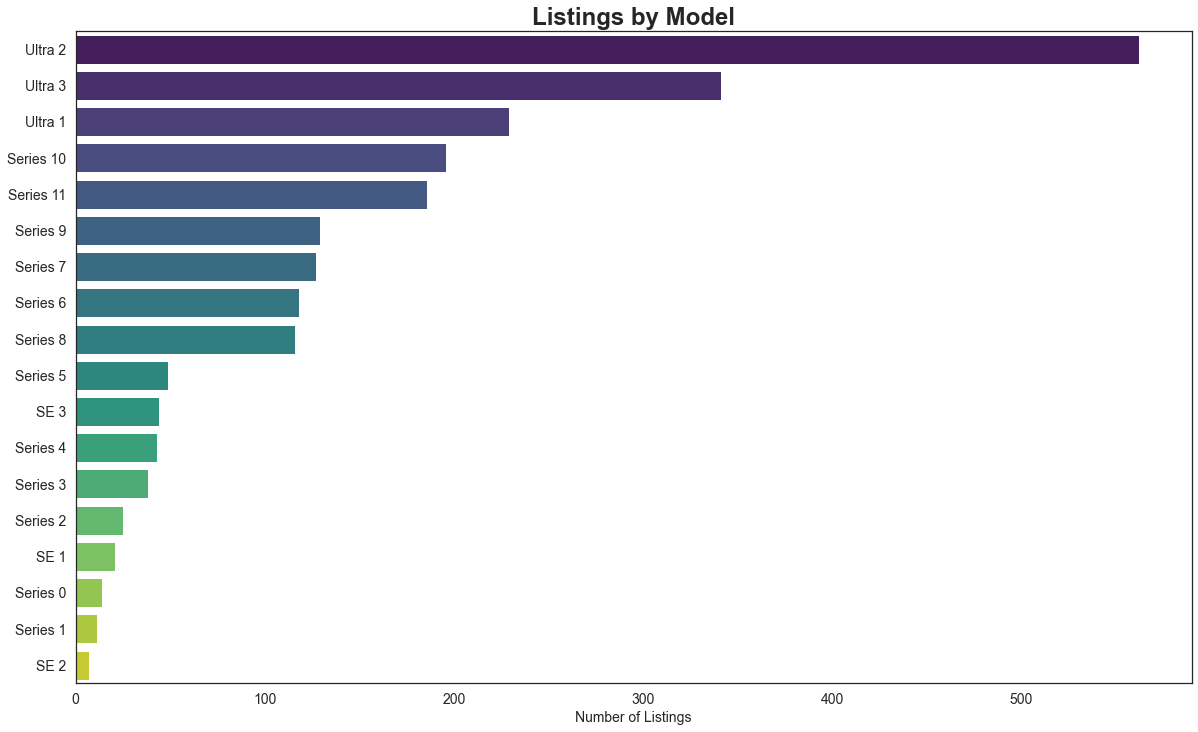

In [366]:
plot_model_by_count(df, palette = 'viridis')